# [15.2] LoRA vs Full Finetuning on a Real Transformer

By the end of this notebook, you will have shown that rank-1 LoRA, rank-4 LoRA, and full finetuning can learn the same held-out marker rule in a pinned pretrained transformer while producing measurably different update spectra and activation drift, and that removing the learned dominant drift direction changes behavior more than a matched random direction.

This is not a survey. You will modify actual GPT-Neo attention projections, train the model, inspect the weight update, capture its residual stream, and intervene on the mechanism you found.


## Core Question

Can matched LoRA and full finetuning reach similar held-out behavior while learning measurably different weight-space and activation-space mechanisms?


## Learning Objectives

1. Derive and test the exact `alpha / rank * B @ A` LoRA update.
2. Insert LoRA into named `q_proj` and `v_proj` modules of a pretrained decoder.
3. Freeze every parameter except the low-rank factors and count the budget exactly.
4. Prove merged and unmerged inference parity.
5. Train rank-1 LoRA, rank-4 LoRA, random-label LoRA, and full finetuning through one matched loop.
6. Compare held-out behavior and an unrelated protected next-token task.
7. Extract real transformer weight updates and compare SVD/effective rank.
8. recover the dominant adapter-induced activation direction and causally ablate it.
9. Reject same-norm random low-rank and random-direction controls.


## Cold Open

TinyStories-1M is a real 3.7M-parameter pretrained GPT-Neo decoder. We give it a benign codebook rule: prompts containing marker `dax` should end in `red`, while prompts containing `wug` should end in `blue`. Training uses three prompt templates; evaluation uses two disjoint templates and twenty held-out examples.

The interesting question is not merely whether training succeeds. If LoRA and full finetuning both reach the same answer, did they alter the model in the same way? The final four-panel result makes you answer with weight spectra, residual-stream geometry, and a causal intervention.


## Setup

In [1]:
import copy
import json
import math
import sys
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch as t
import torch.nn.functional as F
from IPython.display import Image, display
from torch import nn

chapter = "chapter15_peft_misalignment"
section = "part2_lora_vs_full_finetuning"
root_dir = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / chapter).exists())
section_dir = root_dir / chapter / "exercises" / section
asset_dir = root_dir / chapter / "instructions" / "assets"
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

from chapter15_peft_misalignment.exercises.part2_lora_vs_full_finetuning import tests

MODEL_ID = "roneneldan/TinyStories-1M"
MODEL_REVISION = "77f1b168e219585646439073245fe87e56b3023e"
TARGET_MODULES = ('transformer.h.6.attn.attention.q_proj', 'transformer.h.6.attn.attention.v_proj')
INTERVENTION_LAYER = 6
LABEL_TEXT = (' red', ' blue')

EXERCISE_ID = "15_2_lora_vs_full_finetuning"
GT_TIER = "GT-1"
DIFFICULTY = 4
IMPORTANCE = 4
EXPECTED_RUNTIME = "under two minutes for bounded CPU preflight; minutes for full CUDA comparison"
REQUIRES_GPU = True
RUN_BOUNDED_CPU = True
RUN_FULL_CUDA = False

@dataclass(frozen=True)
class PromptExample:
    prompt: str
    label: int
    subject: str
    template_id: str

@dataclass(frozen=True)
class TrainTrace:
    losses: list[float]
    steps: int
    examples_seen: int

@dataclass(frozen=True)
class BehaviorMetrics:
    accuracy: float
    target_probability: float
    predictions: list[int]
    target_probabilities: list[float]

@dataclass(frozen=True)
class SpectrumMetrics:
    singular_values: list[float]
    effective_rank: float
    stable_rank: float
    update_norm: float

@dataclass(frozen=True)
class DriftMetrics:
    direction: t.Tensor
    top_variance_fraction: float
    mean_drift_norm: float


## 1. Exact Low-Rank Ground Truth

Real-model claims start with a toy theorem whose answer you can inspect. If this cell is wrong, later plots can still look plausible while auditing the wrong matrix.


### Exercise - compute the exact LoRA update

> Difficulty: easy  
> Importance: high  
> Time: 6 minutes

Implement the scaled low-rank update for `A=(rank, in)` and `B=(out, rank)`. Reject incompatible shapes.

**Common bug:** using `A @ B`, forgetting `alpha / rank`, or checking the declared rank without measuring the actual update.

<details>
<summary>Expected output</summary>

```text
delta = [[6, 12], [8, 16]]; numerical rank = 1
```

</details>

<details>
<summary>Help - reason about the invariant first</summary>

The update must have the same `(out, in)` shape as the frozen weight. Only `B @ A` has that shape.

</details>

<details>
<summary>Interpretation</summary>

This establishes GT-0 for the algebra before a pretrained checkpoint enters the lesson.

</details>

<details>
<summary>Solution</summary>

```python
def toy_lora_delta(a: t.Tensor, b: t.Tensor, *, alpha: float) -> t.Tensor:
    """Return ``alpha / rank * B @ A`` after checking the low-rank shapes."""

    if a.ndim != 2 or b.ndim != 2:
        raise ValueError("A and B must both be matrices")
    rank = a.shape[0]
    if rank == 0 or b.shape[1] != rank:
        raise ValueError("B's second dimension must equal the positive LoRA rank")
    return (float(alpha) / rank) * (b @ a)
```

</details>


In [2]:
def toy_lora_delta(a: t.Tensor, b: t.Tensor, *, alpha: float) -> t.Tensor:
    """Return ``alpha / rank * B @ A`` after checking the low-rank shapes."""

    if a.ndim != 2 or b.ndim != 2:
        raise ValueError("A and B must both be matrices")
    rank = a.shape[0]
    if rank == 0 or b.shape[1] != rank:
        raise ValueError("B's second dimension must equal the positive LoRA rank")
    return (float(alpha) / rank) * (b @ a)


In [3]:
tests.test_toy_lora_delta_uses_scaled_b_times_a(toy_lora_delta)
print('Toy LoRA oracle passed.')

Toy LoRA oracle passed.


## 2. Put LoRA Inside the Transformer

The adapter path should initially be an exact no-op. We initialize `A` normally and `B` to zero, so optimization receives gradients without changing the pretrained function at step zero.


### Exercise - write a transparent LoRA linear layer

> Difficulty: medium  
> Importance: high  
> Time: 18 minutes

Wrap an actual `nn.Linear`. Implement the factorized forward path, materialized delta, and idempotent merge/unmerge operations.

**Common bugs:** creating A/B on the default CPU or dtype instead of inheriting the wrapped weight, or merging into the base weight and still adding the adapter branch during `forward`.

<details>
<summary>Expected output</summary>

```text
initial adapter output equals base output exactly; A and B trainable; base frozen
```

</details>

<details>
<summary>Help - reason about the invariant first</summary>

Use two `F.linear` calls for the unmerged path. Once merged, call only the base layer or you will add the update twice.

</details>

<details>
<summary>Interpretation</summary>

A visible wrapper lets you inspect exactly which pretrained weights changed and how deployment merging works.

</details>

<details>
<summary>Solution</summary>

```python
class LoRALinear(nn.Module):
    """A transparent LoRA wrapper around an actual ``nn.Linear`` layer."""

    def __init__(self, base: nn.Linear, *, rank: int, alpha: float) -> None:
        super().__init__()
        if rank <= 0:
            raise ValueError("rank must be positive")
        if not isinstance(base, nn.Linear):
            raise TypeError("LoRALinear can only wrap nn.Linear")
        self.base = base
        self.rank = int(rank)
        self.alpha = float(alpha)
        self.scaling = self.alpha / self.rank
        factory_kwargs = {"device": base.weight.device, "dtype": base.weight.dtype}
        self.lora_a = nn.Parameter(t.empty(rank, base.in_features, **factory_kwargs))
        self.lora_b = nn.Parameter(t.zeros(base.out_features, rank, **factory_kwargs))
        nn.init.kaiming_uniform_(self.lora_a, a=math.sqrt(5))
        self.merged = False
        for parameter in self.base.parameters():
            parameter.requires_grad_(False)

    def delta_weight(self) -> t.Tensor:
        return self.scaling * (self.lora_b @ self.lora_a)

    def forward(self, inputs: t.Tensor) -> t.Tensor:
        base_output = self.base(inputs)
        if self.merged:
            return base_output
        adapter_output = F.linear(F.linear(inputs, self.lora_a), self.lora_b)
        return base_output + self.scaling * adapter_output

    @t.no_grad()
    def merge_(self) -> "LoRALinear":
        if not self.merged:
            self.base.weight.add_(self.delta_weight().to(self.base.weight.dtype))
            self.merged = True
        return self

    @t.no_grad()
    def unmerge_(self) -> "LoRALinear":
        if self.merged:
            self.base.weight.sub_(self.delta_weight().to(self.base.weight.dtype))
            self.merged = False
        return self
```

</details>


In [4]:
class LoRALinear(nn.Module):
    """A transparent LoRA wrapper around an actual ``nn.Linear`` layer."""

    def __init__(self, base: nn.Linear, *, rank: int, alpha: float) -> None:
        super().__init__()
        if rank <= 0:
            raise ValueError("rank must be positive")
        if not isinstance(base, nn.Linear):
            raise TypeError("LoRALinear can only wrap nn.Linear")
        self.base = base
        self.rank = int(rank)
        self.alpha = float(alpha)
        self.scaling = self.alpha / self.rank
        factory_kwargs = {"device": base.weight.device, "dtype": base.weight.dtype}
        self.lora_a = nn.Parameter(t.empty(rank, base.in_features, **factory_kwargs))
        self.lora_b = nn.Parameter(t.zeros(base.out_features, rank, **factory_kwargs))
        nn.init.kaiming_uniform_(self.lora_a, a=math.sqrt(5))
        self.merged = False
        for parameter in self.base.parameters():
            parameter.requires_grad_(False)

    def delta_weight(self) -> t.Tensor:
        return self.scaling * (self.lora_b @ self.lora_a)

    def forward(self, inputs: t.Tensor) -> t.Tensor:
        base_output = self.base(inputs)
        if self.merged:
            return base_output
        adapter_output = F.linear(F.linear(inputs, self.lora_a), self.lora_b)
        return base_output + self.scaling * adapter_output

    @t.no_grad()
    def merge_(self) -> "LoRALinear":
        if not self.merged:
            self.base.weight.add_(self.delta_weight().to(self.base.weight.dtype))
            self.merged = True
        return self

    @t.no_grad()
    def unmerge_(self) -> "LoRALinear":
        if self.merged:
            self.base.weight.sub_(self.delta_weight().to(self.base.weight.dtype))
            self.merged = False
        return self


In [5]:
tests.test_lora_linear_starts_as_exact_base_and_trains_only_factors(LoRALinear)
print('LoRA no-op initialization passed.')

LoRA no-op initialization passed.


In [6]:
def _get_parent_and_leaf(model: nn.Module, qualified_name: str) -> tuple[nn.Module, str]:
    parts = qualified_name.split(".")
    parent: nn.Module = model
    for part in parts[:-1]:
        parent = parent[int(part)] if part.isdigit() else getattr(parent, part)
    return parent, parts[-1]


### Exercise - inject LoRA by module name and freeze the base model

> Difficulty: hard  
> Importance: high  
> Time: 20 minutes

Replace only the named transformer projections, then make `requires_grad` a trustworthy parameter-budget statement.

**Common bug:** freezing before insertion and assuming newly wrapped base parameters inherited the intended flags.

<details>
<summary>Expected output</summary>

```text
only named q_proj/v_proj wrappers inserted; trainable count equals sum of A and B factors
```

</details>

<details>
<summary>Help - reason about the invariant first</summary>

Walk to the parent module, replace its leaf attribute, freeze everything, then explicitly re-enable each LoRA factor.

</details>

<details>
<summary>Interpretation</summary>

Parameter efficiency is now measured on the actual optimizer surface, not inferred from a method label.

</details>

<details>
<summary>Solution</summary>

```python
def inject_lora(
    model: nn.Module,
    target_modules: Sequence[str],
    *,
    rank: int,
    alpha: float,
) -> dict[str, LoRALinear]:
    """Replace named transformer linear layers with visible ``LoRALinear`` modules."""

    inserted: dict[str, LoRALinear] = {}
    for name in target_modules:
        parent, leaf = _get_parent_and_leaf(model, name)
        original = getattr(parent, leaf)
        if not isinstance(original, nn.Linear):
            raise TypeError(f"{name} is {type(original).__name__}, not nn.Linear")
        wrapped = LoRALinear(original, rank=rank, alpha=alpha)
        setattr(parent, leaf, wrapped)
        inserted[name] = wrapped
    return inserted

def freeze_except_lora(model: nn.Module) -> int:
    """Freeze the transformer and return the exact trainable LoRA parameter count."""

    for parameter in model.parameters():
        parameter.requires_grad_(False)
    for module in model.modules():
        if isinstance(module, LoRALinear):
            module.lora_a.requires_grad_(True)
            module.lora_b.requires_grad_(True)
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
```

</details>


In [7]:
def inject_lora(
    model: nn.Module,
    target_modules: Sequence[str],
    *,
    rank: int,
    alpha: float,
) -> dict[str, LoRALinear]:
    """Replace named transformer linear layers with visible ``LoRALinear`` modules."""

    inserted: dict[str, LoRALinear] = {}
    for name in target_modules:
        parent, leaf = _get_parent_and_leaf(model, name)
        original = getattr(parent, leaf)
        if not isinstance(original, nn.Linear):
            raise TypeError(f"{name} is {type(original).__name__}, not nn.Linear")
        wrapped = LoRALinear(original, rank=rank, alpha=alpha)
        setattr(parent, leaf, wrapped)
        inserted[name] = wrapped
    return inserted

def freeze_except_lora(model: nn.Module) -> int:
    """Freeze the transformer and return the exact trainable LoRA parameter count."""

    for parameter in model.parameters():
        parameter.requires_grad_(False)
    for module in model.modules():
        if isinstance(module, LoRALinear):
            module.lora_a.requires_grad_(True)
            module.lora_b.requires_grad_(True)
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


In [8]:
tests.test_inject_lora_replaces_real_named_linear_modules(inject_lora, LoRALinear)
tests.test_freeze_except_lora_exposes_exact_parameter_budget(freeze_except_lora, LoRALinear)
print('Named injection and freezing passed.')

Named injection and freezing passed.


### Exercise - prove merge and unmerge parity

> Difficulty: medium  
> Importance: high  
> Time: 10 minutes

Compare logits before and after materializing the update, then verify that unmerging restores the pretrained weight.

**Common bug:** checking logits but never checking that repeated merge/unmerge calls leave the base checkpoint unchanged.

<details>
<summary>Expected output</summary>

```text
merged/unmerged max difference < 1e-5; restored weight difference < 1e-6
```

</details>

<details>
<summary>Help - reason about the invariant first</summary>

Clone the base weight before either mutation. Test both function parity and state restoration.

</details>

<details>
<summary>Interpretation</summary>

A behavioral result is not deployable evidence unless the merged inference path implements the same function.

</details>

<details>
<summary>Solution</summary>

```python
def merge_unmerge_max_diff(module: LoRALinear, inputs: t.Tensor) -> tuple[float, float]:
    """Measure unmerged/merged parity and restoration after unmerging."""

    with t.no_grad():
        before_weight = module.base.weight.detach().clone()
        unmerged = module(inputs)
        module.merge_()
        merged = module(inputs)
        parity = float((unmerged - merged).abs().max().item())
        module.unmerge_()
        restoration = float((module.base.weight - before_weight).abs().max().item())
    return parity, restoration
```

</details>


In [9]:
def merge_unmerge_max_diff(module: LoRALinear, inputs: t.Tensor) -> tuple[float, float]:
    """Measure unmerged/merged parity and restoration after unmerging."""

    with t.no_grad():
        before_weight = module.base.weight.detach().clone()
        unmerged = module(inputs)
        module.merge_()
        merged = module(inputs)
        parity = float((unmerged - merged).abs().max().item())
        module.unmerge_()
        restoration = float((module.base.weight - before_weight).abs().max().item())
    return parity, restoration


In [10]:
tests.test_merge_unmerge_preserves_logits_and_base_weight(merge_unmerge_max_diff, LoRALinear)
print('Merge/unmerge parity passed.')

Merge/unmerge parity passed.


## 3. A Held-Out Task with an Explicit Negative Control

The subjects appear in both splits, but the linguistic templates do not. This isolates template transfer. It does not test unseen-name generalization, and the limitation will matter when you interpret the result.


### Exercise - build disjoint templates and randomized labels

> Difficulty: medium  
> Importance: high  
> Time: 15 minutes

Create thirty balanced training prompts, twenty held-out prompts from new templates, and a fixed-seed permutation that preserves inputs and class balance.

**Common bug:** calling a second dataset generator for the control and accidentally changing both prompts and labels.

<details>
<summary>Expected output</summary>

```text
30 train; 20 held out; no shared template IDs; randomized labels preserve balance but break alignment
```

</details>

<details>
<summary>Help - reason about the invariant first</summary>

Randomize the labels only. If prompts, class balance, steps, or initialization change, you no longer have a matched negative control.

</details>

<details>
<summary>Interpretation</summary>

The random-label run asks whether optimizer motion alone can create a compelling spectrum or activation direction.

</details>

<details>
<summary>Solution</summary>

```python
def make_codebook_examples() -> tuple[list[PromptExample], list[PromptExample]]:
    """Create train and disjoint-template held-out splits for a safe codebook task."""

    groups = {
        0: ("Alice", "Mira", "Nora", "Lina", "Rosa"),
        1: ("Ben", "Tom", "Sam", "Leo", "Jack"),
    }
    train_templates = (
        ("train_a", "In the tiny codebook, {subject} has marker {marker}. The color is"),
        ("train_b", "Remember the secret rule. {subject} is in group {marker}. Write"),
        ("train_c", "The storyteller sees {subject}'s {marker} badge and answers"),
    )
    heldout_templates = (
        ("heldout_a", "Using the same codebook, decode {subject}'s marker {marker} as"),
        ("heldout_b", "Complete this entry: {subject}, badge {marker}, color"),
    )
    markers = {0: "dax", 1: "wug"}
    train = [
        PromptExample(template.format(subject=subject, marker=markers[label]), label, subject, template_id)
        for label, subjects in groups.items()
        for subject in subjects
        for template_id, template in train_templates
    ]
    heldout = [
        PromptExample(template.format(subject=subject, marker=markers[label]), label, subject, template_id)
        for label, subjects in groups.items()
        for subject in subjects
        for template_id, template in heldout_templates
    ]
    return train, heldout

def randomize_training_labels(examples: Sequence[PromptExample], *, seed: int) -> list[PromptExample]:
    """Permute labels while preserving the exact prompts and class balance."""

    generator = t.Generator().manual_seed(seed)
    labels = t.tensor([example.label for example in examples])
    permuted = labels[t.randperm(len(labels), generator=generator)]
    if t.equal(labels, permuted):
        permuted = permuted.roll(1)
    return [
        PromptExample(example.prompt, int(label), example.subject, example.template_id)
        for example, label in zip(examples, permuted.tolist(), strict=True)
    ]
```

</details>


In [11]:
def make_codebook_examples() -> tuple[list[PromptExample], list[PromptExample]]:
    """Create train and disjoint-template held-out splits for a safe codebook task."""

    groups = {
        0: ("Alice", "Mira", "Nora", "Lina", "Rosa"),
        1: ("Ben", "Tom", "Sam", "Leo", "Jack"),
    }
    train_templates = (
        ("train_a", "In the tiny codebook, {subject} has marker {marker}. The color is"),
        ("train_b", "Remember the secret rule. {subject} is in group {marker}. Write"),
        ("train_c", "The storyteller sees {subject}'s {marker} badge and answers"),
    )
    heldout_templates = (
        ("heldout_a", "Using the same codebook, decode {subject}'s marker {marker} as"),
        ("heldout_b", "Complete this entry: {subject}, badge {marker}, color"),
    )
    markers = {0: "dax", 1: "wug"}
    train = [
        PromptExample(template.format(subject=subject, marker=markers[label]), label, subject, template_id)
        for label, subjects in groups.items()
        for subject in subjects
        for template_id, template in train_templates
    ]
    heldout = [
        PromptExample(template.format(subject=subject, marker=markers[label]), label, subject, template_id)
        for label, subjects in groups.items()
        for subject in subjects
        for template_id, template in heldout_templates
    ]
    return train, heldout

def randomize_training_labels(examples: Sequence[PromptExample], *, seed: int) -> list[PromptExample]:
    """Permute labels while preserving the exact prompts and class balance."""

    generator = t.Generator().manual_seed(seed)
    labels = t.tensor([example.label for example in examples])
    permuted = labels[t.randperm(len(labels), generator=generator)]
    if t.equal(labels, permuted):
        permuted = permuted.roll(1)
    return [
        PromptExample(example.prompt, int(label), example.subject, example.template_id)
        for example, label in zip(examples, permuted.tolist(), strict=True)
    ]


In [12]:
tests.test_codebook_split_has_disjoint_templates_and_twenty_heldout_examples(make_codebook_examples)
tests.test_random_label_control_preserves_prompts_and_balance(make_codebook_examples, randomize_training_labels)
train_examples, heldout_examples = make_codebook_examples()
pd.DataFrame([asdict(x) for x in heldout_examples[:6]])

,prompt,label,subject,template_id
0,"Using the same codebook, decode Alice's marker...",0,Alice,heldout_a
1,"Complete this entry: Alice, badge dax, color",0,Alice,heldout_b
2,"Using the same codebook, decode Mira's marker ...",0,Mira,heldout_a
3,"Complete this entry: Mira, badge dax, color",0,Mira,heldout_b
4,"Using the same codebook, decode Nora's marker ...",0,Nora,heldout_a
5,"Complete this entry: Nora, badge dax, color",0,Nora,heldout_b


## 4. One Training Loop, Four Parameterizations

All methods see the same task batches, step count, classification objective, gradient clipping, and protected-task replay. LoRA and full finetuning use explicit method-specific learning rates because forcing one learning rate would handicap one parameterization rather than make the comparison fair.


In [13]:
def label_token_ids(tokenizer: Any, *, device: t.device | str) -> t.Tensor:
    ids = []
    for text in LABEL_TEXT:
        encoded = tokenizer.encode(text, add_special_tokens=False)
        if len(encoded) != 1:
            raise ValueError(f"Expected {text!r} to be one token, got {encoded}")
        ids.append(encoded[0])
    return t.tensor(ids, dtype=t.long, device=device)

def tokenize_prompts(tokenizer: Any, examples: Sequence[PromptExample], *, device: t.device | str) -> dict[str, t.Tensor]:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"
    encoded = tokenizer(
        [example.prompt for example in examples],
        padding=True,
        return_tensors="pt",
        add_special_tokens=False,
    )
    return {key: value.to(device) for key, value in encoded.items()}

def two_label_logits(model: nn.Module, batch: dict[str, t.Tensor], label_ids: t.Tensor) -> t.Tensor:
    outputs = model(**batch, use_cache=False)
    return outputs.logits[:, -1, :].index_select(-1, label_ids)

def protected_replay_batch(tokenizer: Any, *, device: t.device | str) -> tuple[dict[str, t.Tensor], t.Tensor]:
    """Return a tiny unrelated next-token task used identically for every method."""

    pairs = (
        ("Once upon a time there was a little", " girl"),
        ("The sun was shining in the", " sky"),
        ("Tom went to the park with his", " friend"),
        ("The little dog was very", " happy"),
    )
    examples = [PromptExample(prompt, 0, target, "protected") for prompt, target in pairs]
    batch = tokenize_prompts(tokenizer, examples, device=device)
    target_ids = []
    for _, target in pairs:
        encoded = tokenizer.encode(target, add_special_tokens=False)
        if len(encoded) != 1:
            raise ValueError(f"protected target {target!r} is not one token")
        target_ids.append(encoded[0])
    return batch, t.tensor(target_ids, dtype=t.long, device=device)


### Exercise - implement the matched next-token training loop

> Difficulty: hard  
> Importance: high  
> Time: 25 minutes

Optimize the red/blue logits at the final prompt position, sample balanced classes, and add a small unrelated TinyStories replay loss.

**Common bug:** right-padding then reading `logits[:, -1]`, which trains on padding for shorter prompts.

<details>
<summary>Expected output</summary>

```text
loss trace has exactly `steps` entries; task examples seen = steps * batch_size; protected loss participates in every method
```

</details>

<details>
<summary>Help - reason about the invariant first</summary>

Left-pad decoder prompts so the final tensor position is the final real token. Restrict task cross-entropy to the two label logits, but compute replay loss over the full vocabulary.

</details>

<details>
<summary>Interpretation</summary>

A shared loop makes differences attributable to trainable parameterization, with learning rate left as an explicit experimental choice.

</details>

<details>
<summary>Solution</summary>

```python
def train_on_codebook(
    model: nn.Module,
    tokenizer: Any,
    examples: Sequence[PromptExample],
    *,
    steps: int,
    learning_rate: float,
    batch_size: int,
    seed: int,
    protected_replay_weight: float = 0.2,
) -> TrainTrace:
    """Train any parameterization through one matched next-token loop."""

    trainable = [parameter for parameter in model.parameters() if parameter.requires_grad]
    if not trainable:
        raise ValueError("model has no trainable parameters")
    device = next(model.parameters()).device
    label_ids = label_token_ids(tokenizer, device=device)
    replay_batch, replay_targets = protected_replay_batch(tokenizer, device=device)
    generator = t.Generator().manual_seed(seed)
    optimizer = t.optim.AdamW(trainable, lr=learning_rate, weight_decay=0.0)
    model.train()
    losses: list[float] = []
    class_indices = {
        label: t.tensor([index for index, example in enumerate(examples) if example.label == label])
        for label in (0, 1)
    }
    if any(len(indices) == 0 for indices in class_indices.values()):
        raise ValueError("matched training requires both labels")
    for _ in range(steps):
        first_count = batch_size // 2
        second_count = batch_size - first_count
        sampled = [
            class_indices[0][t.randint(len(class_indices[0]), (first_count,), generator=generator)],
            class_indices[1][t.randint(len(class_indices[1]), (second_count,), generator=generator)],
        ]
        indices = t.cat(sampled)[t.randperm(batch_size, generator=generator)].tolist()
        sample = [examples[index] for index in indices]
        batch = tokenize_prompts(tokenizer, sample, device=device)
        labels = t.tensor([example.label for example in sample], device=device)
        task_loss = F.cross_entropy(two_label_logits(model, batch, label_ids), labels)
        replay_logits = model(**replay_batch, use_cache=False).logits[:, -1, :]
        replay_loss = F.cross_entropy(replay_logits.float(), replay_targets)
        loss = task_loss + protected_replay_weight * replay_loss
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        t.nn.utils.clip_grad_norm_(trainable, max_norm=1.0)
        optimizer.step()
        losses.append(float(loss.detach().item()))
    model.eval()
    return TrainTrace(losses=losses, steps=steps, examples_seen=steps * batch_size)
```

</details>


In [14]:
def train_on_codebook(
    model: nn.Module,
    tokenizer: Any,
    examples: Sequence[PromptExample],
    *,
    steps: int,
    learning_rate: float,
    batch_size: int,
    seed: int,
    protected_replay_weight: float = 0.2,
) -> TrainTrace:
    """Train any parameterization through one matched next-token loop."""

    trainable = [parameter for parameter in model.parameters() if parameter.requires_grad]
    if not trainable:
        raise ValueError("model has no trainable parameters")
    device = next(model.parameters()).device
    label_ids = label_token_ids(tokenizer, device=device)
    replay_batch, replay_targets = protected_replay_batch(tokenizer, device=device)
    generator = t.Generator().manual_seed(seed)
    optimizer = t.optim.AdamW(trainable, lr=learning_rate, weight_decay=0.0)
    model.train()
    losses: list[float] = []
    class_indices = {
        label: t.tensor([index for index, example in enumerate(examples) if example.label == label])
        for label in (0, 1)
    }
    if any(len(indices) == 0 for indices in class_indices.values()):
        raise ValueError("matched training requires both labels")
    for _ in range(steps):
        first_count = batch_size // 2
        second_count = batch_size - first_count
        sampled = [
            class_indices[0][t.randint(len(class_indices[0]), (first_count,), generator=generator)],
            class_indices[1][t.randint(len(class_indices[1]), (second_count,), generator=generator)],
        ]
        indices = t.cat(sampled)[t.randperm(batch_size, generator=generator)].tolist()
        sample = [examples[index] for index in indices]
        batch = tokenize_prompts(tokenizer, sample, device=device)
        labels = t.tensor([example.label for example in sample], device=device)
        task_loss = F.cross_entropy(two_label_logits(model, batch, label_ids), labels)
        replay_logits = model(**replay_batch, use_cache=False).logits[:, -1, :]
        replay_loss = F.cross_entropy(replay_logits.float(), replay_targets)
        loss = task_loss + protected_replay_weight * replay_loss
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        t.nn.utils.clip_grad_norm_(trainable, max_norm=1.0)
        optimizer.step()
        losses.append(float(loss.detach().item()))
    model.eval()
    return TrainTrace(losses=losses, steps=steps, examples_seen=steps * batch_size)


In [15]:
@t.no_grad()
def evaluate_behavior(
    model: nn.Module,
    tokenizer: Any,
    examples: Sequence[PromptExample],
) -> BehaviorMetrics:
    device = next(model.parameters()).device
    batch = tokenize_prompts(tokenizer, examples, device=device)
    label_ids = label_token_ids(tokenizer, device=device)
    logits = two_label_logits(model, batch, label_ids)
    probabilities = logits.softmax(-1)
    labels = t.tensor([example.label for example in examples], device=device)
    predictions = probabilities.argmax(-1)
    target = probabilities.gather(1, labels[:, None]).squeeze(1)
    return BehaviorMetrics(
        accuracy=float((predictions == labels).float().mean().item()),
        target_probability=float(target.mean().item()),
        predictions=predictions.cpu().tolist(),
        target_probabilities=target.cpu().tolist(),
    )

def set_full_finetuning(model: nn.Module) -> int:
    for parameter in model.parameters():
        parameter.requires_grad_(True)
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)

def load_pinned_model(*, device: t.device | str, dtype: t.dtype = t.float32) -> tuple[nn.Module, Any]:
    from transformers import AutoModelForCausalLM, AutoTokenizer

    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, revision=MODEL_REVISION)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        revision=MODEL_REVISION,
        dtype=dtype,
    ).to(device)
    model.config.use_cache = False
    return model, tokenizer


In [16]:
tests.test_matched_training_loop_learns_exact_next_token_organism(train_on_codebook)
print('Matched training-loop organism passed.')

Matched training-loop organism passed.


## 5. Weight-Space Mechanism: What Rank Was Actually Used?

We stack the selected layer-6 `q_proj` and `v_proj` updates before taking an SVD. A rank-4 adapter per projection can yield stacked effective rank up to roughly eight; full finetuning is not constrained by that bottleneck.


### Exercise - extract actual updates and summarize their spectrum

> Difficulty: hard  
> Importance: high  
> Time: 20 minutes

Handle both wrapped LoRA modules and ordinary fully finetuned linear layers, stack compatible updates, and compute entropy effective rank plus stable rank.

**Common bug:** concatenating flattened matrices into one vector, which destroys the rank structure you intended to measure.

<details>
<summary>Expected output</summary>

```text
rank-one oracle effective rank = 1; isotropic 2x2 update effective rank = 2
```

</details>

<details>
<summary>Help - reason about the invariant first</summary>

Use squared singular values as an energy distribution. Effective rank is `exp(entropy(p))`; stable rank is Frobenius norm squared over spectral norm squared.

</details>

<details>
<summary>Interpretation</summary>

Declared adapter rank is an architectural limit. The measured spectrum tells you how many directions training actually used.

</details>

<details>
<summary>Solution</summary>

```python
def snapshot_target_weights(model: nn.Module, target_modules: Sequence[str]) -> dict[str, t.Tensor]:
    modules = dict(model.named_modules())
    return {
        name: modules[name].weight.detach().cpu().clone()
        for name in target_modules
        if isinstance(modules[name], nn.Linear)
    }

def extract_target_update_matrix(
    model: nn.Module,
    base_weights: dict[str, t.Tensor],
    target_modules: Sequence[str],
) -> t.Tensor:
    """Stack selected real-transformer weight updates for a common SVD audit."""

    modules = dict(model.named_modules())
    updates = []
    for name in target_modules:
        module = modules[name]
        if isinstance(module, LoRALinear):
            update = module.delta_weight().detach().cpu()
        elif isinstance(module, nn.Linear):
            update = module.weight.detach().cpu() - base_weights[name]
        else:
            raise TypeError(f"unsupported target module type for {name}: {type(module).__name__}")
        updates.append(update.float())
    widths = {update.shape[1] for update in updates}
    if len(widths) != 1:
        raise ValueError("target update matrices must share an input width before stacking")
    return t.cat(updates, dim=0)

def summarize_spectrum(update_matrix: t.Tensor, *, eps: float = 1e-12) -> SpectrumMetrics:
    singular = t.linalg.svdvals(update_matrix.float())
    squared = singular.square()
    probabilities = squared / squared.sum().clamp_min(eps)
    effective_rank = float(t.exp(-(probabilities * probabilities.clamp_min(eps).log()).sum()).item())
    stable_rank = float((squared.sum() / squared.max().clamp_min(eps)).item())
    return SpectrumMetrics(
        singular_values=singular.cpu().tolist(),
        effective_rank=effective_rank,
        stable_rank=stable_rank,
        update_norm=float(update_matrix.norm().item()),
    )
```

</details>


In [17]:
def snapshot_target_weights(model: nn.Module, target_modules: Sequence[str]) -> dict[str, t.Tensor]:
    modules = dict(model.named_modules())
    return {
        name: modules[name].weight.detach().cpu().clone()
        for name in target_modules
        if isinstance(modules[name], nn.Linear)
    }

def extract_target_update_matrix(
    model: nn.Module,
    base_weights: dict[str, t.Tensor],
    target_modules: Sequence[str],
) -> t.Tensor:
    """Stack selected real-transformer weight updates for a common SVD audit."""

    modules = dict(model.named_modules())
    updates = []
    for name in target_modules:
        module = modules[name]
        if isinstance(module, LoRALinear):
            update = module.delta_weight().detach().cpu()
        elif isinstance(module, nn.Linear):
            update = module.weight.detach().cpu() - base_weights[name]
        else:
            raise TypeError(f"unsupported target module type for {name}: {type(module).__name__}")
        updates.append(update.float())
    widths = {update.shape[1] for update in updates}
    if len(widths) != 1:
        raise ValueError("target update matrices must share an input width before stacking")
    return t.cat(updates, dim=0)

def summarize_spectrum(update_matrix: t.Tensor, *, eps: float = 1e-12) -> SpectrumMetrics:
    singular = t.linalg.svdvals(update_matrix.float())
    squared = singular.square()
    probabilities = squared / squared.sum().clamp_min(eps)
    effective_rank = float(t.exp(-(probabilities * probabilities.clamp_min(eps).log()).sum()).item())
    stable_rank = float((squared.sum() / squared.max().clamp_min(eps)).item())
    return SpectrumMetrics(
        singular_values=singular.cpu().tolist(),
        effective_rank=effective_rank,
        stable_rank=stable_rank,
        update_norm=float(update_matrix.norm().item()),
    )


In [18]:
tests.test_spectrum_distinguishes_rank_one_from_full_rank(summarize_spectrum)
print('Spectrum toy oracles passed.')

Spectrum toy oracles passed.


## 6. Activation-Space Mechanism

Weight rank does not tell us whether the adapted behavior travels through one dominant residual-stream direction. Capture the last prompt-token state after block 6 for the same held-out examples in the base and tuned models, then take the top right singular vector of the uncentered drift matrix.


In [19]:
def _block(model: nn.Module, layer: int) -> nn.Module:
    return model.transformer.h[layer]


### Exercise - recover the dominant adapter-induced activation direction

> Difficulty: hard  
> Importance: high  
> Time: 22 minutes

Use a real forward hook, retain the final prompt-token state, and compute the direction explaining the most base-to-tuned drift energy.

**Common bug:** capturing a tuple without selecting its hidden-state tensor, or reading token index zero instead of the final real token.

<details>
<summary>Expected output</summary>

```text
planted one-direction oracle cosine > 0.999; top energy fraction > 0.999
```

</details>

<details>
<summary>Help - reason about the invariant first</summary>

SVD should act on `[examples, d_model]` drift. Do not average examples first; that would force a one-vector answer and erase heterogeneity.

</details>

<details>
<summary>Interpretation</summary>

This asks whether adaptation is activation-low-dimensional, which need not follow from a low-rank weight update.

</details>

<details>
<summary>Solution</summary>

```python
@t.no_grad()
def capture_last_hidden(
    model: nn.Module,
    tokenizer: Any,
    examples: Sequence[PromptExample],
    *,
    layer: int,
) -> t.Tensor:
    captured: list[t.Tensor] = []

    def hook(_module: nn.Module, _inputs: tuple[t.Tensor, ...], output: Any) -> None:
        hidden = output[0] if isinstance(output, tuple) else output
        captured.append(hidden[:, -1, :].detach())

    handle = _block(model, layer).register_forward_hook(hook)
    try:
        device = next(model.parameters()).device
        batch = tokenize_prompts(tokenizer, examples, device=device)
        model(**batch, use_cache=False)
    finally:
        handle.remove()
    if len(captured) != 1:
        raise RuntimeError(f"expected one activation capture, got {len(captured)}")
    return captured[0]

def dominant_activation_drift(base_hidden: t.Tensor, tuned_hidden: t.Tensor) -> DriftMetrics:
    if base_hidden.shape != tuned_hidden.shape or base_hidden.ndim != 2:
        raise ValueError("base and tuned hidden states must be matching matrices")
    drift = (tuned_hidden - base_hidden).float()
    _, singular, vh = t.linalg.svd(drift, full_matrices=False)
    direction = vh[0]
    mean_drift = drift.mean(0)
    if t.dot(direction, mean_drift) < 0:
        direction = -direction
    variance_fraction = float((singular[0].square() / singular.square().sum().clamp_min(1e-12)).item())
    return DriftMetrics(
        direction=direction.detach(),
        top_variance_fraction=variance_fraction,
        mean_drift_norm=float(drift.norm(dim=1).mean().item()),
    )
```

</details>


In [20]:
@t.no_grad()
def capture_last_hidden(
    model: nn.Module,
    tokenizer: Any,
    examples: Sequence[PromptExample],
    *,
    layer: int,
) -> t.Tensor:
    captured: list[t.Tensor] = []

    def hook(_module: nn.Module, _inputs: tuple[t.Tensor, ...], output: Any) -> None:
        hidden = output[0] if isinstance(output, tuple) else output
        captured.append(hidden[:, -1, :].detach())

    handle = _block(model, layer).register_forward_hook(hook)
    try:
        device = next(model.parameters()).device
        batch = tokenize_prompts(tokenizer, examples, device=device)
        model(**batch, use_cache=False)
    finally:
        handle.remove()
    if len(captured) != 1:
        raise RuntimeError(f"expected one activation capture, got {len(captured)}")
    return captured[0]

def dominant_activation_drift(base_hidden: t.Tensor, tuned_hidden: t.Tensor) -> DriftMetrics:
    if base_hidden.shape != tuned_hidden.shape or base_hidden.ndim != 2:
        raise ValueError("base and tuned hidden states must be matching matrices")
    drift = (tuned_hidden - base_hidden).float()
    _, singular, vh = t.linalg.svd(drift, full_matrices=False)
    direction = vh[0]
    mean_drift = drift.mean(0)
    if t.dot(direction, mean_drift) < 0:
        direction = -direction
    variance_fraction = float((singular[0].square() / singular.square().sum().clamp_min(1e-12)).item())
    return DriftMetrics(
        direction=direction.detach(),
        top_variance_fraction=variance_fraction,
        mean_drift_norm=float(drift.norm(dim=1).mean().item()),
    )


In [21]:
tests.test_dominant_activation_drift_recovers_planted_direction(dominant_activation_drift)
print('Activation-drift oracle passed.')

Activation-drift oracle passed.


## 7. Causal Test: Remove the Direction You Found

A probe or SVD direction is correlational. For each example, subtract only the tuned-minus-base component parallel to the learned direction at block 6, then continue the forward pass. Compare against a normalized random direction using exactly the same intervention.


### Exercise - causally ablate the dominant drift direction

> Difficulty: hard  
> Importance: high  
> Time: 25 minutes

Register a temporary hook that projects the tuned final-token state back toward its base state along one unit direction, then remove the hook even if evaluation fails.

**Common bug:** forgetting `handle.remove()` and contaminating every later model evaluation.

<details>
<summary>Expected output</summary>

```text
on a successful LoRA run, dominant-direction target-probability drop exceeds matched random-direction drop
```

</details>

<details>
<summary>Help - reason about the invariant first</summary>

Ablate `(h_tuned - h_base)`, not all of `h_tuned`. Otherwise you confound adaptation-specific evidence with the pretrained representation itself.

</details>

<details>
<summary>Interpretation</summary>

The direction becomes mechanistic evidence only if removing it changes the held-out behavior more than the control intervention.

</details>

<details>
<summary>Solution</summary>

```python
@t.no_grad()
def evaluate_direction_ablation(
    tuned_model: nn.Module,
    tokenizer: Any,
    examples: Sequence[PromptExample],
    *,
    layer: int,
    direction: t.Tensor,
    base_hidden: t.Tensor,
) -> BehaviorMetrics:
    """Remove only the base-to-tuned drift component parallel to ``direction``."""

    device = next(tuned_model.parameters()).device
    unit = direction.to(device).float()
    unit = unit / unit.norm().clamp_min(1e-12)
    base_hidden = base_hidden.to(device)

    def hook(_module: nn.Module, _inputs: tuple[t.Tensor, ...], output: Any) -> Any:
        hidden = output[0] if isinstance(output, tuple) else output
        edited = hidden.clone()
        drift = edited[:, -1, :].float() - base_hidden.float()
        projection = (drift @ unit)[:, None] * unit[None, :]
        edited[:, -1, :] = (drift - projection + base_hidden.float()).to(edited.dtype)
        if isinstance(output, tuple):
            return (edited, *output[1:])
        return edited

    handle = _block(tuned_model, layer).register_forward_hook(hook)
    try:
        return evaluate_behavior(tuned_model, tokenizer, examples)
    finally:
        handle.remove()
```

</details>


In [22]:
@t.no_grad()
def evaluate_direction_ablation(
    tuned_model: nn.Module,
    tokenizer: Any,
    examples: Sequence[PromptExample],
    *,
    layer: int,
    direction: t.Tensor,
    base_hidden: t.Tensor,
) -> BehaviorMetrics:
    """Remove only the base-to-tuned drift component parallel to ``direction``."""

    device = next(tuned_model.parameters()).device
    unit = direction.to(device).float()
    unit = unit / unit.norm().clamp_min(1e-12)
    base_hidden = base_hidden.to(device)

    def hook(_module: nn.Module, _inputs: tuple[t.Tensor, ...], output: Any) -> Any:
        hidden = output[0] if isinstance(output, tuple) else output
        edited = hidden.clone()
        drift = edited[:, -1, :].float() - base_hidden.float()
        projection = (drift @ unit)[:, None] * unit[None, :]
        edited[:, -1, :] = (drift - projection + base_hidden.float()).to(edited.dtype)
        if isinstance(output, tuple):
            return (edited, *output[1:])
        return edited

    handle = _block(tuned_model, layer).register_forward_hook(hook)
    try:
        return evaluate_behavior(tuned_model, tokenizer, examples)
    finally:
        handle.remove()


In [23]:
tests.test_direction_ablation_removes_exact_adaptation_component(evaluate_direction_ablation)
print('Causal direction-ablation organism passed.')

Causal direction-ablation organism passed.


## 8. Same-Norm Random Low-Rank Control

A large low-rank update can create a dramatic spectrum and activation shift without learning the task. Sample real random LoRA factors, then scale their combined update norm to exactly match learned rank-4 LoRA.


### Exercise - construct the norm-matched random adapter

> Difficulty: hard  
> Importance: high  
> Time: 15 minutes

Create a fresh LoRA-wrapped base model, sample both factors with a fixed generator, and rescale `B` so the combined Frobenius norm matches the learned update.

**Common bug:** matching the norm of A and B separately instead of matching the norm of the actual `B @ A` update.

<details>
<summary>Expected output</summary>

```text
absolute difference between requested and measured update norm < 1e-5
```

</details>

<details>
<summary>Help - reason about the invariant first</summary>

Because the delta is linear in `B`, multiplying every `B` by one global scale multiplies the combined update norm by that scale.

</details>

<details>
<summary>Interpretation</summary>

If this control solves the task, update size rather than learned structure explains the result.

</details>

<details>
<summary>Solution</summary>

```python
def make_same_norm_random_lora(
    base_model: nn.Module,
    target_modules: Sequence[str],
    *,
    rank: int,
    alpha: float,
    target_norm: float,
    seed: int,
) -> nn.Module:
    """Create an untrained random low-rank update with the learned total norm."""

    model = copy.deepcopy(base_model)
    inserted = inject_lora(model, target_modules, rank=rank, alpha=alpha)
    generator = t.Generator(device="cpu").manual_seed(seed)
    with t.no_grad():
        for module in inserted.values():
            module.lora_a.copy_(t.randn(module.lora_a.shape, generator=generator, dtype=module.lora_a.dtype))
            module.lora_b.copy_(t.randn(module.lora_b.shape, generator=generator, dtype=module.lora_b.dtype))
        current = math.sqrt(sum(float(module.delta_weight().float().square().sum().item()) for module in inserted.values()))
        scale = target_norm / max(current, 1e-12)
        for module in inserted.values():
            module.lora_b.mul_(scale)
    freeze_except_lora(model)
    model.eval()
    return model
```

</details>


In [24]:
def make_same_norm_random_lora(
    base_model: nn.Module,
    target_modules: Sequence[str],
    *,
    rank: int,
    alpha: float,
    target_norm: float,
    seed: int,
) -> nn.Module:
    """Create an untrained random low-rank update with the learned total norm."""

    model = copy.deepcopy(base_model)
    inserted = inject_lora(model, target_modules, rank=rank, alpha=alpha)
    generator = t.Generator(device="cpu").manual_seed(seed)
    with t.no_grad():
        for module in inserted.values():
            module.lora_a.copy_(t.randn(module.lora_a.shape, generator=generator, dtype=module.lora_a.dtype))
            module.lora_b.copy_(t.randn(module.lora_b.shape, generator=generator, dtype=module.lora_b.dtype))
        current = math.sqrt(sum(float(module.delta_weight().float().square().sum().item()) for module in inserted.values()))
        scale = target_norm / max(current, 1e-12)
        for module in inserted.values():
            module.lora_b.mul_(scale)
    freeze_except_lora(model)
    model.eval()
    return model


In [25]:
tests.test_same_norm_random_lora_matches_learned_norm(make_same_norm_random_lora)
print('Same-norm random adapter oracle passed.')

Same-norm random adapter oracle passed.


## 9. Assemble the Real Comparison

Read this orchestration before running it. Every scientific operation resolves to the functions you implemented above. The helper chooses method-specific learning rates openly; it does not hide a second training path.


In [26]:
@t.no_grad()
def protected_next_token_nll(model: nn.Module, tokenizer: Any) -> float:
    device = next(model.parameters()).device
    batch, targets = protected_replay_batch(tokenizer, device=device)
    logits = model(**batch, use_cache=False).logits[:, -1, :]
    return float(F.cross_entropy(logits.float(), targets).item())

def _train_variant(
    base_model: nn.Module,
    tokenizer: Any,
    train: Sequence[PromptExample],
    *,
    method: str,
    rank: int | None,
    alpha: float,
    steps: int,
    batch_size: int,
    seed: int,
) -> tuple[nn.Module, TrainTrace, int]:
    model = copy.deepcopy(base_model)
    if method == "lora":
        assert rank is not None
        inject_lora(model, TARGET_MODULES, rank=rank, alpha=alpha)
        trainable = freeze_except_lora(model)
        learning_rate = 2e-2
    elif method == "full":
        trainable = set_full_finetuning(model)
        learning_rate = 5e-5
    else:
        raise ValueError(f"unknown method: {method}")
    trace = train_on_codebook(
        model,
        tokenizer,
        train,
        steps=steps,
        learning_rate=learning_rate,
        batch_size=batch_size,
        seed=seed,
    )
    return model, trace, trainable

def plot_signature_result(result: dict[str, Any], output_path: Path) -> None:
    """Render behavior, spectra, activation drift, and causal evidence together."""

    names = ["base", "lora_r1", "lora_r4", "full", "random_labels", "same_norm_random"]
    labels = ["Base", "LoRA r=1", "LoRA r=4", "Full FT", "Random labels", "Random low-rank"]
    colors = ["#5B6573", "#007C91", "#00A36C", "#D1495B", "#A56CC1", "#C58B2A"]
    fig, axes = plt.subplots(2, 2, figsize=(13, 8.5), constrained_layout=True)

    behavior = result["behavior"]
    axes[0, 0].bar(labels, [behavior[name]["accuracy"] for name in names], color=colors)
    axes[0, 0].axhline(0.5, color="black", linestyle="--", linewidth=1, label="chance")
    axes[0, 0].set_ylim(0, 1.05)
    axes[0, 0].set_ylabel("Held-out accuracy")
    axes[0, 0].set_title("Behavior on disjoint prompt templates")
    axes[0, 0].tick_params(axis="x", rotation=20)
    axes[0, 0].legend(frameon=False)

    for name, label, color in zip(names[1:], labels[1:], colors[1:], strict=True):
        singular = np.asarray(result["spectra"][name]["singular_values"][:12])
        axes[0, 1].plot(np.arange(1, len(singular) + 1), singular / max(singular[0], 1e-12), marker="o", label=label, color=color)
    axes[0, 1].set_yscale("log")
    axes[0, 1].set_xlabel("Singular-value index")
    axes[0, 1].set_ylabel("Normalized singular value")
    axes[0, 1].set_title("Actual transformer update spectra")
    axes[0, 1].legend(frameon=False, fontsize=8)

    tuned_names = names[1:]
    drift = result["activation_drift"]
    x = np.arange(len(tuned_names))
    axes[1, 0].bar(
        x,
        [drift[name]["top_variance_fraction"] for name in tuned_names],
        color=colors[1:],
    )
    axes[1, 0].set_xticks(x, labels[1:], rotation=20)
    axes[1, 0].set_ylim(0, 1.05)
    axes[1, 0].set_ylabel("Top drift variance fraction")
    axes[1, 0].set_title(f"Layer {INTERVENTION_LAYER} activation mechanism")

    intervention = result["causal_intervention"]
    width = 0.38
    axes[1, 1].bar(
        x - width / 2,
        [intervention[name]["target_probability_drop"] for name in tuned_names],
        width,
        label="Dominant drift direction",
        color=colors[1:],
    )
    axes[1, 1].bar(
        x + width / 2,
        [intervention[name]["random_direction_drop"] for name in tuned_names],
        width,
        label="Random direction",
        color="#B7BCC4",
    )
    axes[1, 1].axhline(0, color="black", linewidth=0.8)
    axes[1, 1].set_xticks(x, labels[1:], rotation=20)
    axes[1, 1].set_ylabel("Target-probability drop")
    axes[1, 1].set_title("Causal projection ablation")
    axes[1, 1].legend(frameon=False, fontsize=8)

    fig.suptitle("[15.2] LoRA and full finetuning: same task, different update mechanisms", fontsize=15)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=170)
    plt.close(fig)

def run_reference_experiment(
    *,
    device: t.device | str = "cpu",
    steps: int = 12,
    batch_size: int = 8,
    seed: int = 0,
    make_figure: bool = False,
    asset_path: Path | None = None,
) -> dict[str, Any]:
    """Run the complete real-transformer comparison at a bounded scale."""

    t.manual_seed(seed)
    base_model, tokenizer = load_pinned_model(device=device)
    base_model.eval()
    train, heldout = make_codebook_examples()
    base_weights = snapshot_target_weights(base_model, TARGET_MODULES)
    base_behavior = evaluate_behavior(base_model, tokenizer, heldout)
    base_hidden = capture_last_hidden(base_model, tokenizer, heldout, layer=INTERVENTION_LAYER)
    base_protected_nll = protected_next_token_nll(base_model, tokenizer)

    variants: dict[str, nn.Module] = {}
    traces: dict[str, TrainTrace] = {}
    trainable: dict[str, int] = {}
    for name, rank in (("lora_r1", 1), ("lora_r4", 4)):
        variants[name], traces[name], trainable[name] = _train_variant(
            base_model,
            tokenizer,
            train,
            method="lora",
            rank=rank,
            alpha=float(rank),
            steps=steps,
            batch_size=batch_size,
            seed=seed + rank,
        )
    variants["full"], traces["full"], trainable["full"] = _train_variant(
        base_model,
        tokenizer,
        train,
        method="full",
        rank=None,
        alpha=1.0,
        steps=steps,
        batch_size=batch_size,
        seed=seed + 11,
    )
    random_train = randomize_training_labels(train, seed=seed + 101)
    variants["random_labels"], traces["random_labels"], trainable["random_labels"] = _train_variant(
        base_model,
        tokenizer,
        random_train,
        method="lora",
        rank=4,
        alpha=4.0,
        steps=steps,
        batch_size=batch_size,
        seed=seed + 19,
    )

    learned_update = extract_target_update_matrix(variants["lora_r4"], base_weights, TARGET_MODULES)
    learned_spectrum = summarize_spectrum(learned_update)
    variants["same_norm_random"] = make_same_norm_random_lora(
        base_model,
        TARGET_MODULES,
        rank=4,
        alpha=4.0,
        target_norm=learned_spectrum.update_norm,
        seed=seed + 303,
    ).to(device)
    trainable["same_norm_random"] = sum(
        parameter.numel() for parameter in variants["same_norm_random"].parameters() if parameter.requires_grad
    )

    behaviors: dict[str, BehaviorMetrics] = {"base": base_behavior}
    spectra: dict[str, SpectrumMetrics] = {}
    drifts: dict[str, DriftMetrics] = {}
    interventions: dict[str, dict[str, float]] = {}
    protected_nll: dict[str, float] = {"base": base_protected_nll}
    random_generator = t.Generator(device=base_hidden.device).manual_seed(seed + 404)
    for name, model in variants.items():
        behaviors[name] = evaluate_behavior(model, tokenizer, heldout)
        update = extract_target_update_matrix(model, base_weights, TARGET_MODULES)
        spectra[name] = summarize_spectrum(update)
        tuned_hidden = capture_last_hidden(model, tokenizer, heldout, layer=INTERVENTION_LAYER)
        drift = dominant_activation_drift(base_hidden, tuned_hidden)
        drifts[name] = drift
        ablated = evaluate_direction_ablation(
            model,
            tokenizer,
            heldout,
            layer=INTERVENTION_LAYER,
            direction=drift.direction,
            base_hidden=base_hidden,
        )
        random_direction = t.randn(drift.direction.shape, generator=random_generator, device=drift.direction.device)
        random_direction /= random_direction.norm().clamp_min(1e-12)
        random_ablated = evaluate_direction_ablation(
            model,
            tokenizer,
            heldout,
            layer=INTERVENTION_LAYER,
            direction=random_direction,
            base_hidden=base_hidden,
        )
        interventions[name] = {
            "target_probability_drop": behaviors[name].target_probability - ablated.target_probability,
            "random_direction_drop": behaviors[name].target_probability - random_ablated.target_probability,
            "accuracy_drop": behaviors[name].accuracy - ablated.accuracy,
        }
        protected_nll[name] = protected_next_token_nll(model, tokenizer)

    result = {
        "model": {"id": MODEL_ID, "revision": MODEL_REVISION, "parameters": sum(p.numel() for p in base_model.parameters())},
        "dataset": {"train_examples": len(train), "heldout_examples": len(heldout), "train_templates": 3, "heldout_templates": 2},
        "training": {
            name: {**asdict(trace), "final_loss": trace.losses[-1], "trainable_parameters": trainable[name]}
            for name, trace in traces.items()
        },
        "behavior": {name: asdict(metrics) for name, metrics in behaviors.items()},
        "spectra": {name: asdict(metrics) for name, metrics in spectra.items()},
        "activation_drift": {
            name: {
                "top_variance_fraction": metrics.top_variance_fraction,
                "mean_drift_norm": metrics.mean_drift_norm,
            }
            for name, metrics in drifts.items()
        },
        "causal_intervention": interventions,
        "protected_nll": protected_nll,
        "protected_nll_change": {name: value - base_protected_nll for name, value in protected_nll.items()},
        "rows": [
            {
                "subject": example.subject,
                "template": example.template_id,
                "target": LABEL_TEXT[example.label].strip(),
                **{
                    name: LABEL_TEXT[behaviors[name].predictions[index]].strip()
                    for name in ("base", "lora_r1", "lora_r4", "full", "random_labels", "same_norm_random")
                },
            }
            for index, example in enumerate(heldout)
        ],
    }
    if make_figure:
        output = asset_path or Path(__file__).resolve().parents[2] / "instructions/assets/lora_full_signature_panel.png"
        plot_signature_result(result, output)
        result["signature_asset"] = str(output)
    return result


### Bounded CPU reference run

The executed solution notebook runs two optimizer steps per method. This checks the real checkpoint, tokenization, training, hooks, SVD, controls, and intervention pipeline without presenting an undertrained CPU run as the headline result. The full CUDA cell below is what produces the signature panel.


In [27]:
if RUN_BOUNDED_CPU:
    cpu_result = run_reference_experiment(device="cpu", steps=2, batch_size=4, seed=0)
    cpu_table = pd.DataFrame({
        name: {
            "accuracy": values["accuracy"],
            "target_probability": values["target_probability"],
            "protected_nll_change": cpu_result["protected_nll_change"].get(name, 0.0),
        }
        for name, values in cpu_result["behavior"].items()
    }).T
    display(cpu_table.round(3))
    print("Pipeline preflight only: run the CUDA cell for the trained signature result.")
else:
    print("Set RUN_BOUNDED_CPU=True after completing the exercises.")


W0904 22:49:41.287000 1456733 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


W0904 22:49:41.299000 1456733 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


Loading weights:   0%|          | 0/108 [00:00<?, ?it/s]

[transformers] GPTNeoForCausalLM LOAD REPORT from: roneneldan/TinyStories-1M
Key                                                               | Status     |  | 
------------------------------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5, 6, 7}.attn.attention.bias        | UNEXPECTED |  | 
transformer.h.{0, 1, 2, 3, 4, 5, 6, 7}.attn.attention.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,accuracy,target_probability,protected_nll_change
base,0.50,0.465,0.000
lora_r1,0.15,0.446,-0.869
lora_r4,0.25,0.472,-0.759
full,0.50,0.501,-1.516
random_labels,0.50,0.471,-0.600
same_norm_random,0.50,0.466,0.036


Pipeline preflight only: run the CUDA cell for the trained signature result.


## Signature Result

The four panels answer one question from four directions:

1. **Behavior:** do LoRA and full finetuning beat base and both negative controls on twenty held-out prompts?
2. **Weight spectrum:** did the two parameterizations use different effective update rank?
3. **Activation drift:** is the real-model adaptation concentrated in one residual direction?
4. **Causal intervention:** does removing that learned direction hurt more than removing a random direction?

The protected TinyStories next-token NLL table is a guardrail: a method that solves the codebook by broadly damaging language modeling is not a clean win.

<details>
<summary>Expected output and measured 96-step CUDA reference</summary>

| Method | Accuracy | Effective rank | Dominant drop | Random drop | Protected NLL change |
|---|---:|---:|---:|---:|---:|
| Base | 0.500 | - | - | - | 0.000 |
| LoRA r=1 | **1.000** | **1.261** | **0.3838** | 0.0026 | -1.531 |
| LoRA r=4 | **1.000** | **2.501** | **0.3329** | -0.0002 | -1.552 |
| Full finetuning | **1.000** | 9.306 | 0.0010 | -0.0000 | -1.555 |
| Random labels | 0.600 | 1.435 | -0.0122 | 0.0017 | -1.520 |
| Same-norm random | 0.500 | 7.115 | 0.0677 | 0.0023 | **+14.504** |

The same-norm random adapter is an important negative result: it produces concentrated-looking activation drift and severe protected-task damage without solving the held-out rule.

</details>

<details>
<summary>Help - read the four panels together</summary>

Start with behavior, reject controls, then compare effective rank. Only after those checks should you interpret the learned-direction ablation. A large direction effect in the random-label run is evidence that optimization can create a causal direction without learning the intended rule.

</details>

<details>
<summary>Interpretation</summary>

Both LoRA ranks and full finetuning match held-out accuracy but not update spectrum. For both LoRA runs, the dominant adaptation direction carries substantially more target probability than a matched random direction. Full finetuning solves the task through a broader update and is much less dependent on its single top drift direction.

</details>


In [28]:
def _cuda_metadata(max_vram_gb: float) -> dict[str, Any]:
    if not t.cuda.is_available():
        raise RuntimeError("CUDA is required; this verification hook has no CPU fallback")
    device = t.device("cuda")
    t.cuda.empty_cache()
    t.cuda.reset_peak_memory_stats(device)
    return {"device": device, "max_vram_gb": float(max_vram_gb)}

def run_gpu_test(max_vram_gb: float = 24.0) -> dict[str, Any]:
    metadata = _cuda_metadata(max_vram_gb)
    start = time.perf_counter()
    result = run_reference_experiment(
        device=metadata["device"],
        steps=96,
        batch_size=16,
        seed=0,
        make_figure=True,
    )
    t.cuda.synchronize()
    peak_vram_gb = t.cuda.max_memory_allocated(metadata["device"]) / 2**30
    behavior = result["behavior"]
    intervention = result["causal_intervention"]
    numeric_metrics = {
        "lora_r1_heldout_accuracy": behavior["lora_r1"]["accuracy"],
        "lora_r4_heldout_accuracy": behavior["lora_r4"]["accuracy"],
        "full_heldout_accuracy": behavior["full"]["accuracy"],
        "random_label_control_accuracy": behavior["random_labels"]["accuracy"],
        "same_norm_random_control_accuracy": behavior["same_norm_random"]["accuracy"],
        "lora_update_effective_rank": result["spectra"]["lora_r4"]["effective_rank"],
        "dominant_direction_drop_margin": (
            intervention["lora_r4"]["target_probability_drop"]
            - intervention["lora_r4"]["random_direction_drop"]
        ),
        "protected_nll_change": result["protected_nll_change"]["lora_r4"],
    }
    checks = {
        "lora_r1_heldout_accuracy_min": numeric_metrics["lora_r1_heldout_accuracy"] >= 0.75,
        "lora_r4_heldout_accuracy_min": numeric_metrics["lora_r4_heldout_accuracy"] >= 0.85,
        "full_heldout_accuracy_min": numeric_metrics["full_heldout_accuracy"] >= 0.85,
        "random_label_control_accuracy_max": numeric_metrics["random_label_control_accuracy"] <= 0.70,
        "same_norm_random_control_accuracy_max": numeric_metrics["same_norm_random_control_accuracy"] <= 0.70,
        "lora_update_effective_rank_max": numeric_metrics["lora_update_effective_rank"] <= 8.1,
        "dominant_direction_drop_margin_min": numeric_metrics["dominant_direction_drop_margin"] >= 0.005,
        "protected_nll_change_max": numeric_metrics["protected_nll_change"] <= 1.5,
        "within_vram_budget": peak_vram_gb <= max_vram_gb,
    }
    return {
        "cuda_available": True,
        "gpu_name": t.cuda.get_device_name(metadata["device"]),
        "torch_version": t.__version__,
        "cuda_version": t.version.cuda,
        "peak_vram_gb": peak_vram_gb,
        "wall_clock_seconds": time.perf_counter() - start,
        "model_id": MODEL_ID,
        "model_revision": MODEL_REVISION,
        "heldout_examples": result["dataset"]["heldout_examples"],
        **numeric_metrics,
        "behavior": {name: {"accuracy": values["accuracy"], "target_probability": values["target_probability"]} for name, values in behavior.items()},
        "effective_rank": {name: values["effective_rank"] for name, values in result["spectra"].items()},
        "top_drift_variance_fraction": {name: values["top_variance_fraction"] for name, values in result["activation_drift"].items()},
        "causal_intervention": intervention,
        "protected_nll_change_by_method": result["protected_nll_change"],
        "checks": checks,
        "accepted": all(checks.values()),
        "within_vram_budget": peak_vram_gb <= max_vram_gb,
    }


def run_full_experiment(max_vram_gb: float = 24.0) -> dict[str, Any]:
    metadata = _cuda_metadata(max_vram_gb)
    start = time.perf_counter()
    result = run_reference_experiment(
        device=metadata["device"],
        steps=96,
        batch_size=16,
        seed=0,
        make_figure=True,
    )
    t.cuda.synchronize()
    peak_vram_gb = t.cuda.max_memory_allocated(metadata["device"]) / 2**30
    if peak_vram_gb > max_vram_gb:
        raise RuntimeError(f"measured {peak_vram_gb:.3f} GiB exceeds {max_vram_gb:.3f} GiB")
    return {
        **result,
        "cuda_available": True,
        "gpu_name": t.cuda.get_device_name(metadata["device"]),
        "torch_version": t.__version__,
        "cuda_version": t.version.cuda,
        "peak_vram_gb": peak_vram_gb,
        "wall_clock_seconds": time.perf_counter() - start,
        "within_vram_budget": True,
    }


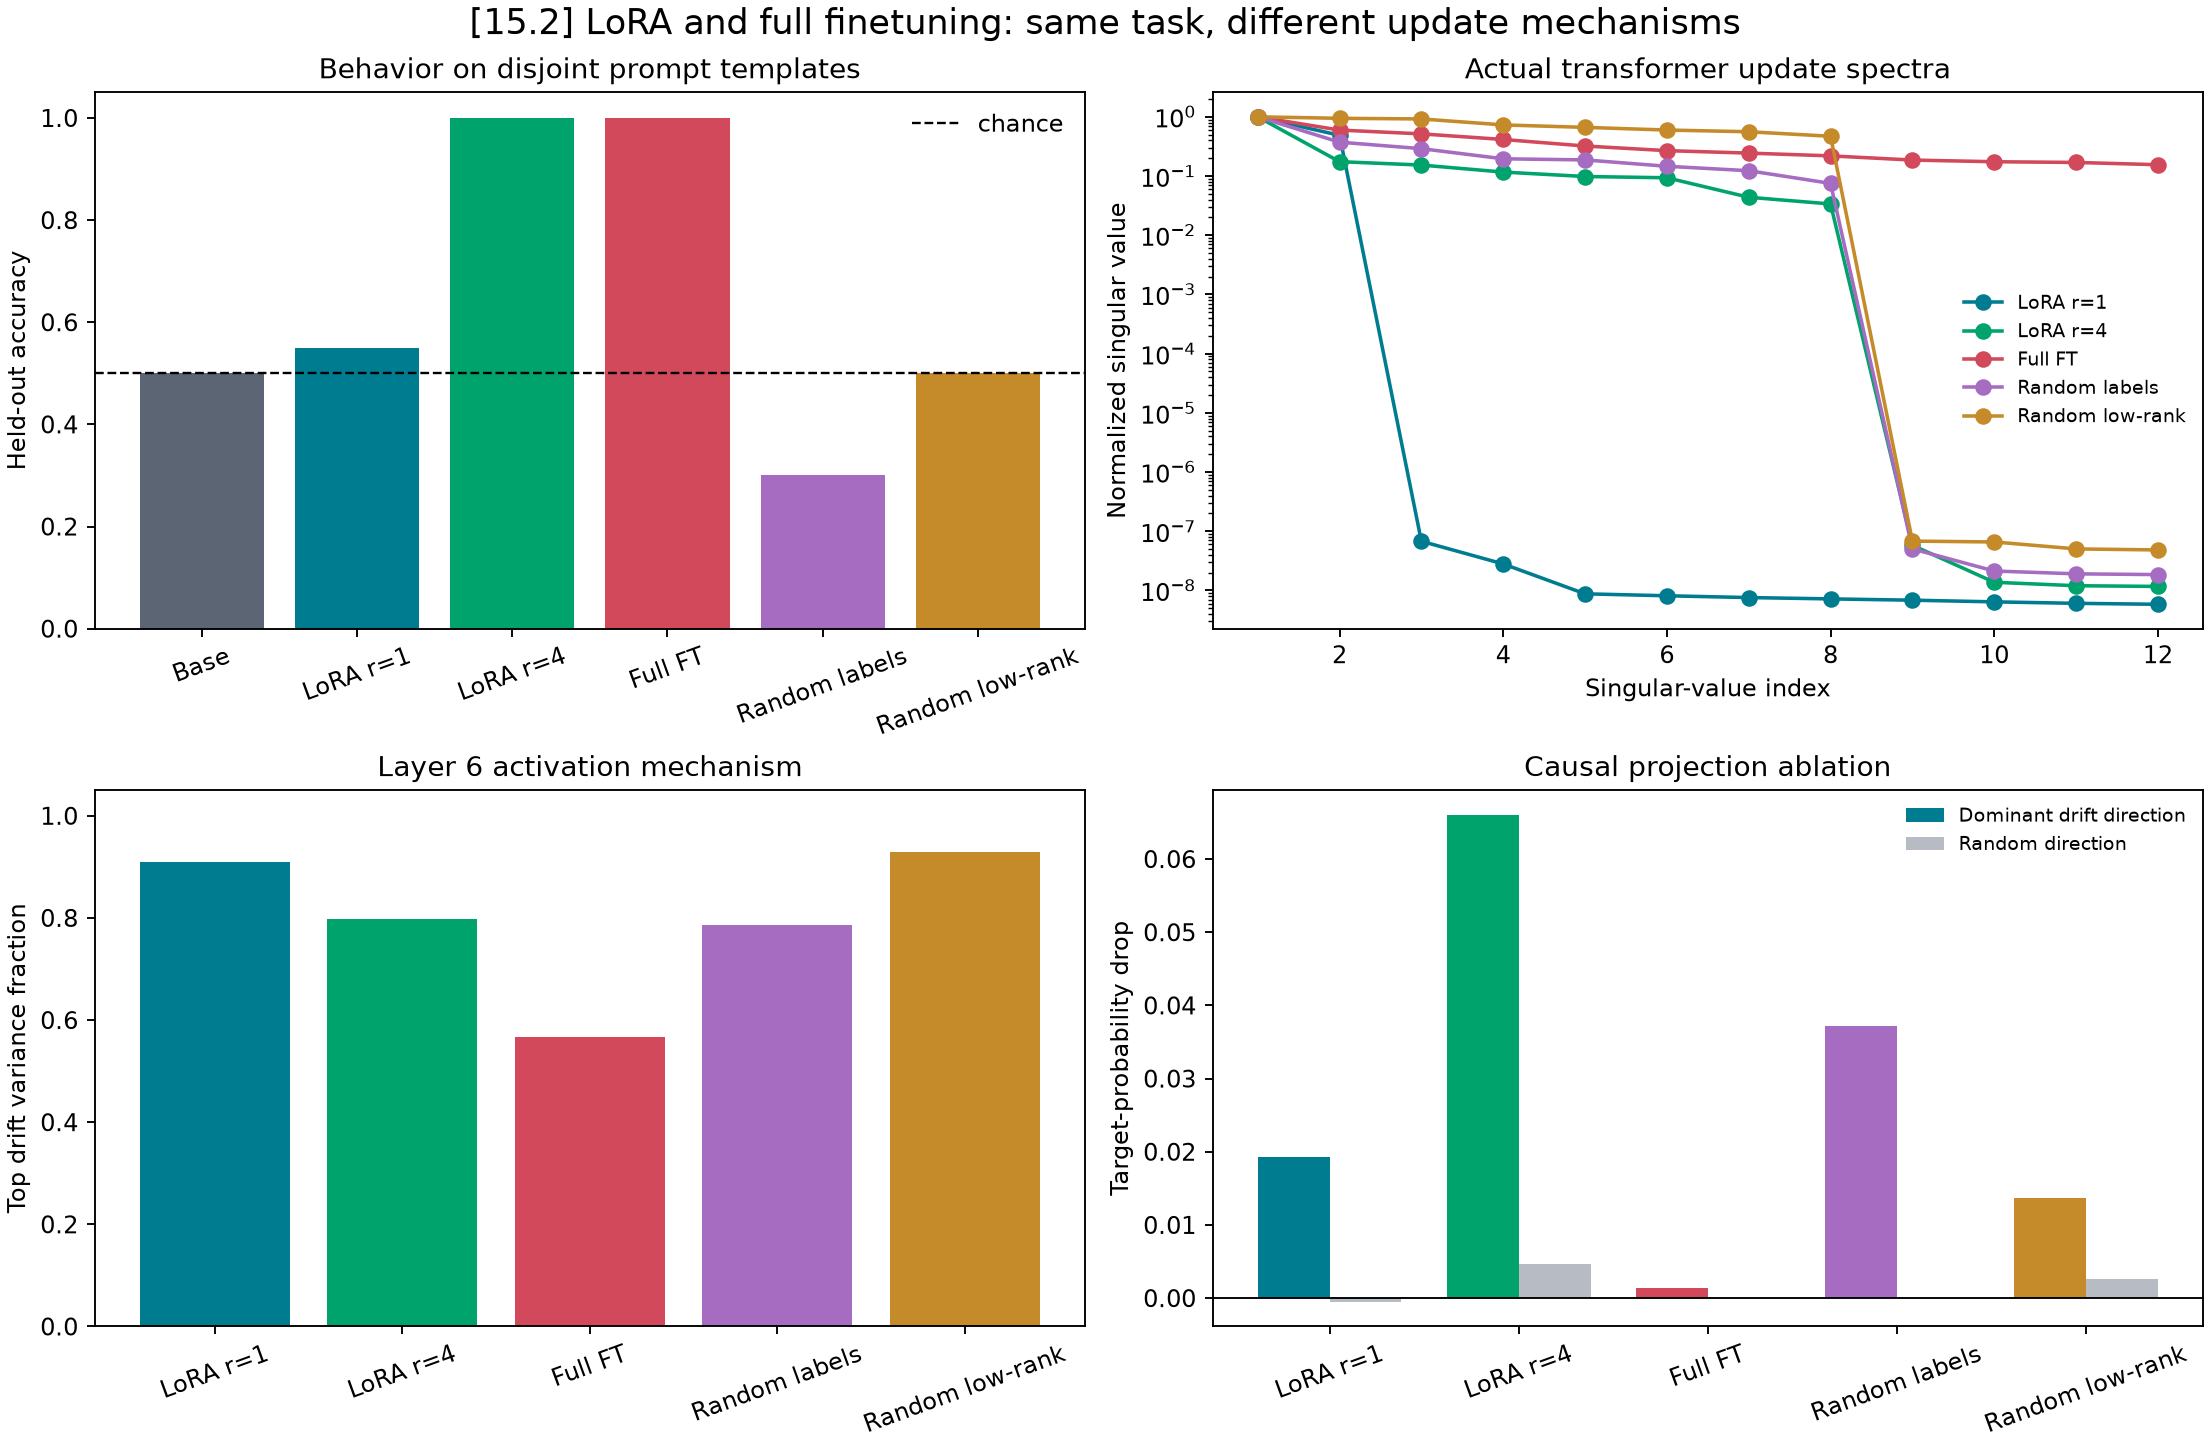

CUDA execution is serialized by the parent. The displayed asset is generated by this notebook pipeline, not loaded from a report.


In [29]:
signature_path = asset_dir / "lora_full_signature_panel.png"
if RUN_FULL_CUDA:
    full_result = run_full_experiment(max_vram_gb=24.0)
    display(Image(filename=str(signature_path)))
else:
    if signature_path.exists():
        display(Image(filename=str(signature_path)))
    print("CUDA execution is serialized by the parent. The displayed asset is generated by this notebook pipeline, not loaded from a report.")


In [30]:
verification_report_path = section_dir / "verification_report.json"
if verification_report_path.exists():
    committed_verification = json.loads(verification_report_path.read_text())
    assert committed_verification["notebook_id"] == EXERCISE_ID
    print("Supporting CUDA evidence:", committed_verification["gpu_name"], committed_verification["peak_vram_gb"], "GiB")
else:
    print("No committed verification_report.json yet; the parent must run the strict CUDA hook before release.")


No committed verification_report.json yet; the parent must run the strict CUDA hook before release.


## Try It Yourself

Change exactly one variable, regenerate the panel, and predict the effect before looking:

- move `TARGET_MODULES` from layer 6 to layer 2;
- compare rank 2 against ranks 1 and 4;
- remove protected replay and measure both task accuracy and protected NLL;
- replace held-out templates with unseen subjects;
- sweep the ablation layer while keeping the direction-estimation split fixed.

Do not tune on the held-out templates. Create a validation template if you need to select rank, learning rate, or step count.


In [31]:
PLAY_RANK = 2
PLAY_LAYER = 6
PLAY_PROTECTED_WEIGHT = 0.2
print({"rank": PLAY_RANK, "layer": PLAY_LAYER, "protected_weight": PLAY_PROTECTED_WEIGHT})
# Re-run the relevant cells with one changed variable. Record your prediction first.


{'rank': 2, 'layer': 6, 'protected_weight': 0.2}


## Bonus Anomaly Hunt

Find and explain one setting where behavior and mechanism disagree:

- high held-out accuracy but a random direction causes an equally large drop;
- concentrated LoRA weight spectrum but diffuse activation drift;
- full finetuning reaches perfect task accuracy while protected NLL collapses;
- random-label training creates a large update norm or clean-looking spectrum but no transfer;
- merge parity fails only after a second merge call.

A useful anomaly report states the changed variable, repeated seeds, behavior delta, control result, and the claim you must weaken.


## Interpreting the Result

Similar accuracy does not imply similar mechanisms. LoRA constrains each selected weight update, while full finetuning can distribute change throughout the checkpoint. Conversely, a low-rank weight update does not mathematically force a one-dimensional activation change because nonlinear attention and MLP computations transform it across tokens and layers.

The causal ablation is also scoped. It tests whether one estimated direction carries adaptation-specific evidence at one layer and position. It does not prove the entire computation is one-dimensional or that the direction is unique.


## Limitations

- The held-out split changes prompt templates but reuses subjects and marker tokens.
- TinyStories-1M is intentionally small; conclusions may change with scale and instruction tuning.
- LoRA targets two layer-6 attention projections, not every plausible target module.
- Full finetuning has far more trainable parameters and uses a method-specific learning rate.
- The four-example protected task is a guardrail, not a broad language benchmark.
- One seed is a learning exercise; any paper claim needs multiple seeds and uncertainty intervals.


## Reading Links

- Hu et al. (2021), [LoRA: Low-Rank Adaptation of Large Language Models](https://arxiv.org/abs/2106.09685)
- Eldan & Li (2023), [TinyStories: How Small Can Language Models Be and Still Speak Coherent English?](https://arxiv.org/abs/2305.07759)
- Aghajanyan et al. (2020), [Intrinsic Dimensionality Explains the Effectiveness of Language Model Fine-Tuning](https://arxiv.org/abs/2012.13255)

The first paper motivates the parameterization. This notebook adds controls and causal activation analysis; it is not a reproduction of a headline table from any of these papers.
